# Домашнє завдання: Прогнозування кредитного ризику

## Мета завдання
Застосувати знання з лекції для побудови моделі логістичної регресії, що прогнозує ймовірність дефолту за кредитом, іншими словами, що людина не поверне кредит. Ви пройдете весь цикл: від дослідницького аналізу до оцінки якості класифікаційної моделі.

## Опис датасету
**Credit Risk Dataset** містить інформацію про 32,000+ позичальників з такими параметрами:
- **person_age**: Вік позичальника
- **person_income**: Річний дохід
- **person_home_ownership**: Тип володіння житлом
- **person_emp_length**: Стаж роботи (в роках)
- **loan_intent**: Мета кредиту
- **loan_grade**: Кредитний рейтинг (A - кращий, F - гірший)
- **loan_amnt**: Сума кредиту
- **loan_int_rate**: Процентна ставка
- **loan_status**: Статус кредиту (0 = сплачено, 1 = дефолт) - **цільова змінна**
- **loan_percent_income**: Відношення кредиту до доходу
- **cb_person_default_on_file**: Історія дефолтів (Y/N)
- **cb_person_cred_hist_length**: Довжина кредитної історії

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `credit_risk_dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (кількість записів, типи колонок)
5. Перевірте розподіл цільової змінної (відсотк даних для кожного класу)

Дайте висновок, це задача збалансованої чи незбалансованої класифікації.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Завантажуємо дані
df = pd.read_csv('/Users/olesialev/Desktop/data:/credit_risk_dataset.csv', sep=None, engine='python')

# Перше знайомство з даними
df.shape

(32581, 12)

In [15]:
df.head(5)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [17]:
# Розподіл статусів кредиту
loan_dist = df['loan_status'].value_counts()
loan_percent = df['loan_status'].value_counts(normalize=True) * 100

print("Кількість записів за кожним класом:")
print(loan_dist)
print("Відсоткове співвідношення:")
print(loan_percent)

Кількість записів за кожним класом:
loan_status
0    25473
1     7108
Name: count, dtype: int64
Відсоткове співвідношення:
loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64


Це незбалансована класифікація, адже клас 0 (позичальники, що повернули кредит) становить приблизно 78.2% даних, а клас 1 (дефолт) становить лише 21.8%.


---

## Завдання 2: Дослідницький аналіз даних (EDA) (4 бали)

**Що потрібно зробити:**
1. Обчисліть відсоток пропущених значень в колонках. За наявності пропущених значень - заповніть їх медіаною для числових колонок і найбільш частим значеннмя для категоріальних.
2. Проаналізуйте розподіл числових змінних.
3. Знайдіть та обробіть викиди в колонці person_income з допомогою [Interquartile range](https://uk.wikipedia.org/wiki/%D0%9C%D1%96%D0%B6%D0%BA%D0%B2%D0%B0%D1%80%D1%82%D0%B8%D0%BB%D1%8C%D0%BD%D0%B8%D0%B9_%D1%80%D0%BE%D0%B7%D0%BC%D0%B0%D1%85).
4. Проаналізуйте категоріальні змінні відносно цільової та частоту зустрічання різних значень в них.
5. Візуалізуйте взаємозв'язок ознак з цільовою змінною.


In [18]:
# 1. Відсоток пропусків
print("Пропуски у відсотках:")
print(df.isnull().mean() * 100)

# Заповнення числових медіаною
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

# Заповнення категоріальних найбільш частим значенням
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Пропуски у відсотках:
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64


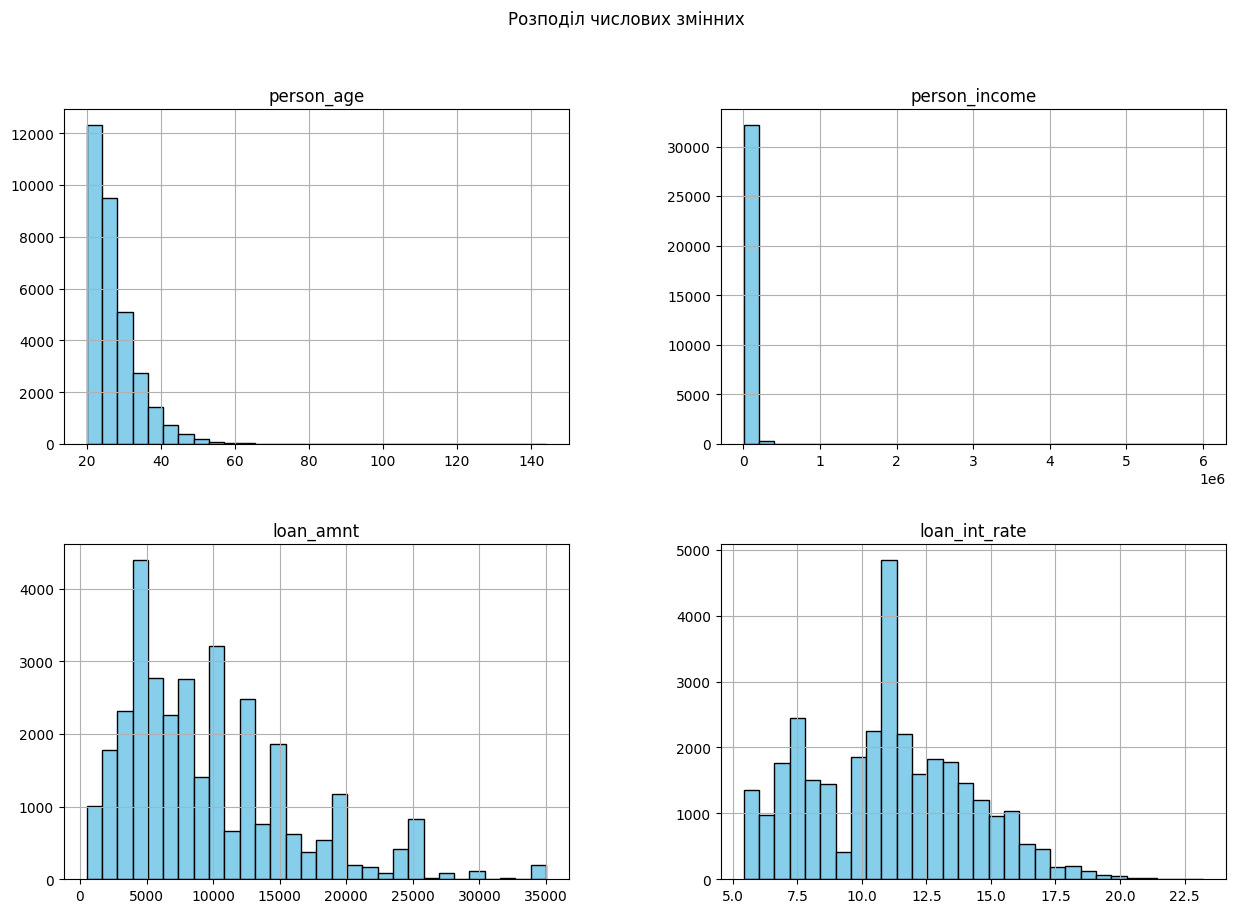

In [19]:
# 2. Аналіз розподілу числових змінних
numeric_cols = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate']

df[numeric_cols].hist(bins=30, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Розподіл числових змінних')
plt.show()

In [20]:
# 3. Обробка викидів у person_income
Q1 = df['person_income'].quantile(0.25)
Q3 = df['person_income'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Оновлений датасет
df_clean = df[(df['person_income'] >= lower_bound) & (df['person_income'] <= upper_bound)].copy()

print(f"Початкова кількість записів: {len(df)}")
print(f"Кількість після видалення викидів: {len(df_clean)}")
print(f"Видалено: {len(df) - len(df_clean)} рядків")

Початкова кількість записів: 32581
Кількість після видалення викидів: 31097
Видалено: 1484 рядків


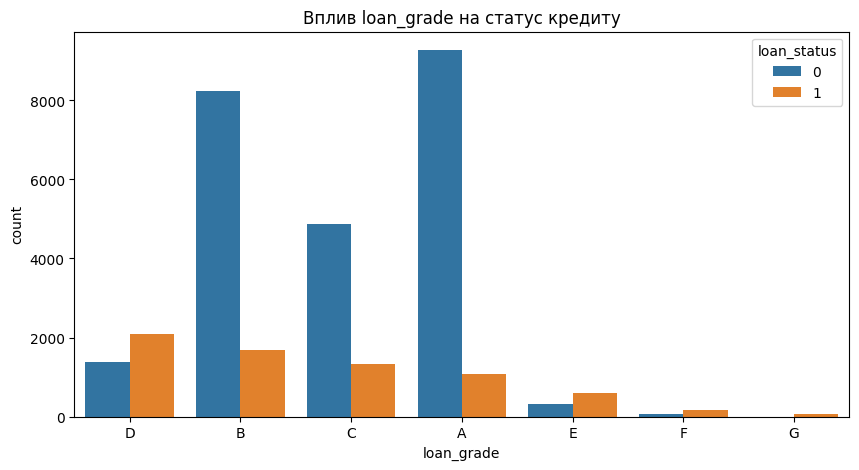

Частота значень для loan_grade:
loan_grade
A    10343
B     9924
C     6191
D     3459
E      899
F      221
G       60
Name: count, dtype: int64


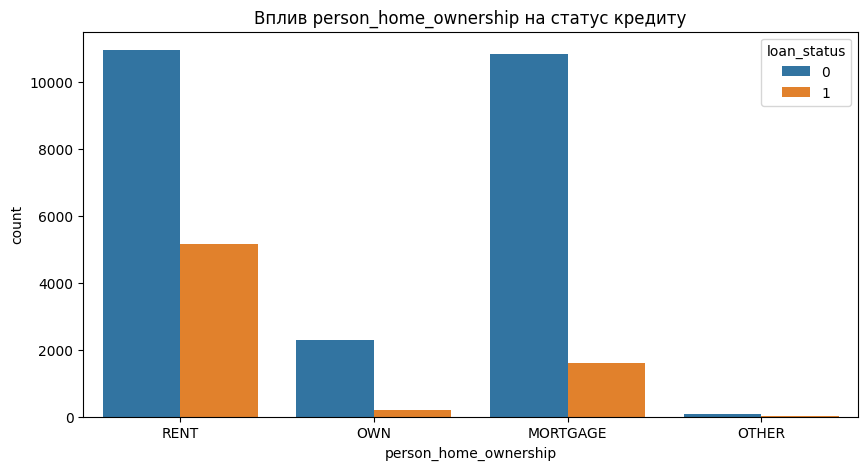

Частота значень для person_home_ownership:
person_home_ownership
RENT        16102
MORTGAGE    12426
OWN          2469
OTHER         100
Name: count, dtype: int64


In [21]:
# 4. Аналіз категоріальних змінних відносно цільової
# Аналіз кредитного рейтингу (loan_grade) та власності на житло (person_home_ownership)
cols_to_analyze = ['loan_grade', 'person_home_ownership']

for col in cols_to_analyze:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='loan_status', data=df_clean)
    plt.title(f'Вплив {col} на статус кредиту')
    plt.show()
    
    # Частота значень
    print(f"Частота значень для {col}:")
    print(df_clean[col].value_counts())

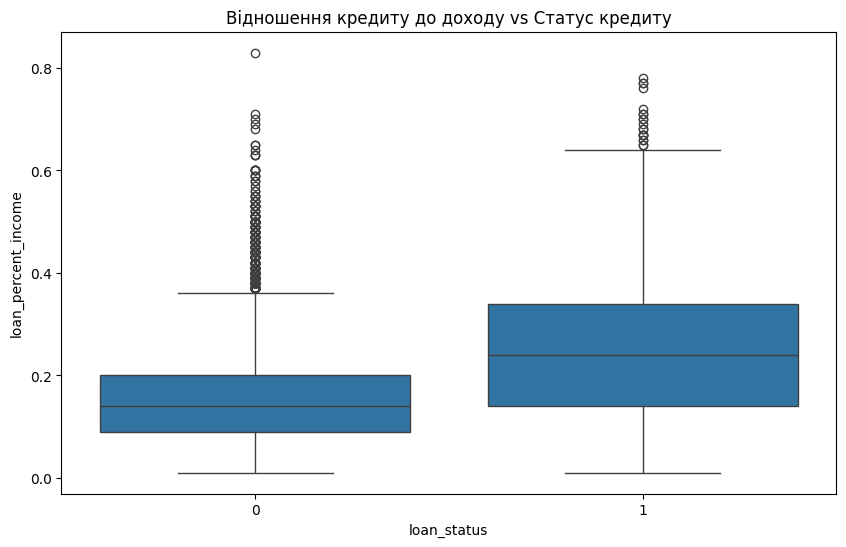

In [22]:
# 5. Візуалізація взаємозв'язку ознак з цільовою змінною
plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df_clean)
plt.title('Відношення кредиту до доходу vs Статус кредиту')
plt.show()

Візуалізація через boxplot показала чітку залежність, що позичальники, які перебувають у стані дефолту, а саме клас 1, в середньому мають вищий показник відношення суми кредиту до річного доходу. Це підтверджує, що надмірне фінансове навантаження є критичним фактором ризику.


---

## Завдання 3: Аналіз кореляцій та Feature Engineering (3 бали)

**Що потрібно зробити:**
1. Побудуйте матрицю кореляцій для числових змінних.
2. Закодуйте категоріальні змінні.
3. Виберіть фінальний набір ознак, можна лишити всі, якщо ви вважаєте, що це - доцільно.



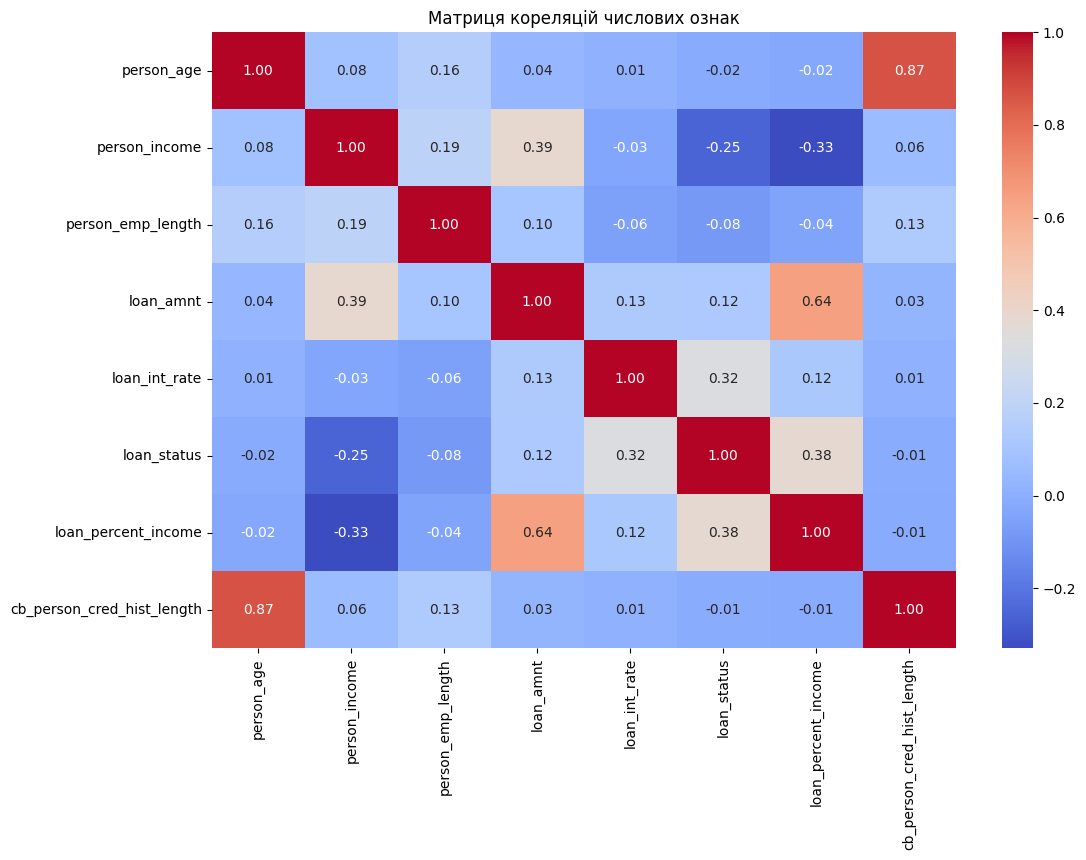

In [25]:
# 1. Матриця кореляцій
numeric_df = df_clean.select_dtypes(include=['number'])

plt.figure(figsize=(12, 8))
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матриця кореляцій числових ознак')
plt.show()

In [28]:
# 2. Кодування категоріальних змінних
selected_cat_cols = [
    'person_home_ownership', 
    'loan_intent', 
    'loan_grade', 
    'cb_person_default_on_file'
]

# One-hot encoding
df_encoded = pd.get_dummies(df_clean, columns=selected_cat_cols, drop_first=True)

df_encoded.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True



---

## Завдання 4: Підготовка даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на X та y
2. Поділіть на навчальну та тестову вибірки
3. Застосуйте масштабування
4. Навчіть модель логістичної регресії
5. Зробіть прогнози на тренувальній та тестовій вибірках.



In [29]:
# 1. Виділяємо цільову змінну та ознаки
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

In [31]:
# 2. Поділ на навчальну та тестову вибірки
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Навчальна вибірка: {X_train.shape[0]} записів")
print(f"Тестова вибірка: {X_test.shape[0]} записів")

Навчальна вибірка: 24877 записів
Тестова вибірка: 6220 записів


In [33]:
# 3. Масштабування
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
# 4. Навчання моделі та прогноз
from sklearn.linear_model import LogisticRegression

# Створюємо модель
log_reg = LogisticRegression(max_iter=1000)

# Навчаємо
log_reg.fit(X_train_scaled, y_train)

# Робимо прогнози
y_train_pred = log_reg.predict(X_train_scaled)
y_test_pred = log_reg.predict(X_test_scaled)

print("Модель успішно навчена")

Модель успішно навчена


In [36]:
log_reg

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


---

## Завдання 5: Оцінка якості моделі (4 бали)

**Що потрібно зробити:**
1. Побудуйте confusion matrix.
2. Обчисліть основні метрики (accuracy, precision, recall, f1).
3. Побудуйте ROC-криву та обчисліть AUC
4. Проаналізуйте важливість ознак.
5. Зробіть висновки про якість моделі та які ознаки найбільше впливають на прогноз.


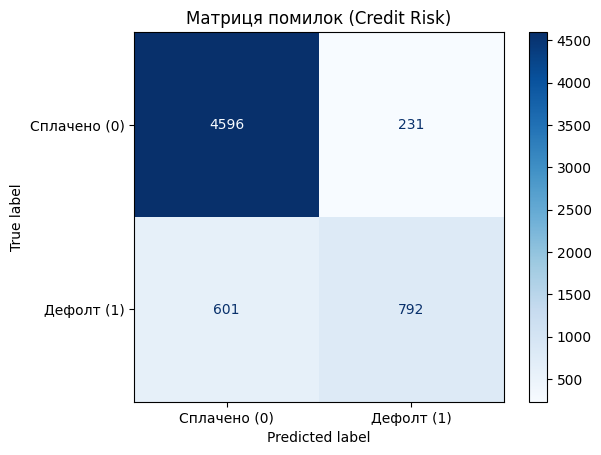

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Створюємо матрицю помилок
cm = confusion_matrix(y_test, y_test_pred)

# Візуалізація
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено (0)', 'Дефолт (1)'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок (Credit Risk)')
plt.show()

In [40]:
# 2. основні метрики (accuracy, precision, recall, f1)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("МЕТРИКИ ЯКОСТІ МОДЕЛІ:")
print(f"Accuracy (Точність):    {accuracy:.3f}")
print(f"Precision (Влучність):  {precision:.3f}")
print(f"Recall (Повнота):       {recall:.3f}")
print(f"F1-score:               {f1:.3f}")

МЕТРИКИ ЯКОСТІ МОДЕЛІ:
Accuracy (Точність):    0.866
Precision (Влучність):  0.774
Recall (Повнота):       0.569
F1-score:               0.656


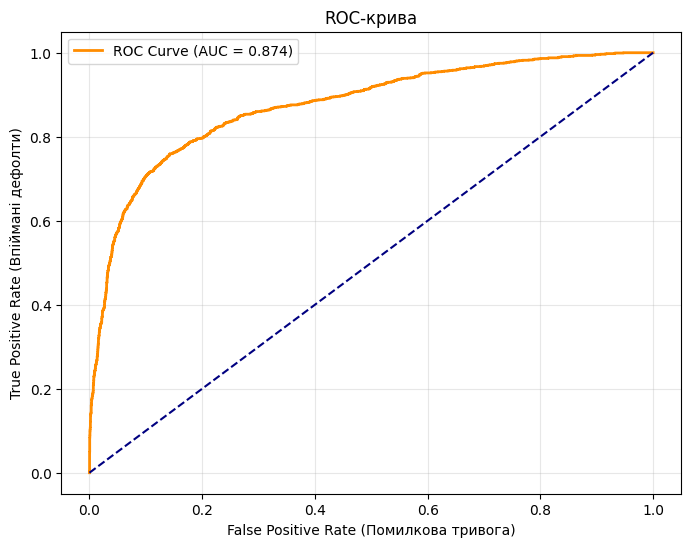

Площа під кривою (AUC): 0.874


In [42]:
# 3. Побудова ROC-кривої та обчислення AUC
from sklearn.metrics import roc_curve, roc_auc_score

# Отримуємо ймовірності прогнозу
y_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_val = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_val:.3f})', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate (Помилкова тривога)')
plt.ylabel('True Positive Rate (Впіймані дефолти)')
plt.title('ROC-крива')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Площа під кривою (AUC): {auc_val:.3f}")

In [45]:
# Отримуємо коефіцієнти моделі 
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': log_reg.coef_[0],
    'abs_coefficient': np.abs(log_reg.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

# Виведемо топ-10 найважливіших ознак
print("Топ-10 найважливіших ознак за модулем:")
print(feature_importance.head(10))


Топ-10 найважливіших ознак за модулем:
                       feature  coefficient  abs_coefficient
5          loan_percent_income     1.318553         1.318553
17                loan_grade_D     0.812938         0.812938
3                    loan_amnt    -0.546248         0.546248
18                loan_grade_E     0.477536         0.477536
8    person_home_ownership_OWN    -0.459162         0.459162
9   person_home_ownership_RENT     0.404043         0.404043
14         loan_intent_VENTURE    -0.400211         0.400211
10       loan_intent_EDUCATION    -0.326753         0.326753
20                loan_grade_G     0.309888         0.309888
19                loan_grade_F     0.269311         0.269311


Модель демонструє високу прогнозовану здатність (AUC = 0.874). Найбільш значущим фактором ризику виявилося фінансове навантаження на позичальника (loan_percent_income): чим вища частка доходу йде на погашення кредиту, тим вища ймовірність дефолту. Хоча загальна точність моделі складає 86.6%, банку варто звернути увагу на Recall (56.9%), що вказує на можливість подальшого покращення моделі, наприклда, через використання складніших алгоритмів. Наявність власного житла та цілі кредиту на освіту чи венчурні проєкти, навпаки, статистично знижують імовірність дефолту в даній вибірці.


---

## Завдання 6: Оптимізація порогу та бізнес-аналіз (2 бали)

**Що потрібно зробити:**
1. Проаналізуйте метрики precision, recall, F1 при різних порогах класифікації (мінімум - 5 різних порогів). Візуалізуйте як змінюються метрики якості при зміні порогу.
2. Оберіть оптимальний поріг для бізнес-задачі - можна обрати виходячи з попереднього пункту, або додати своїх роздумів і обрати інший.



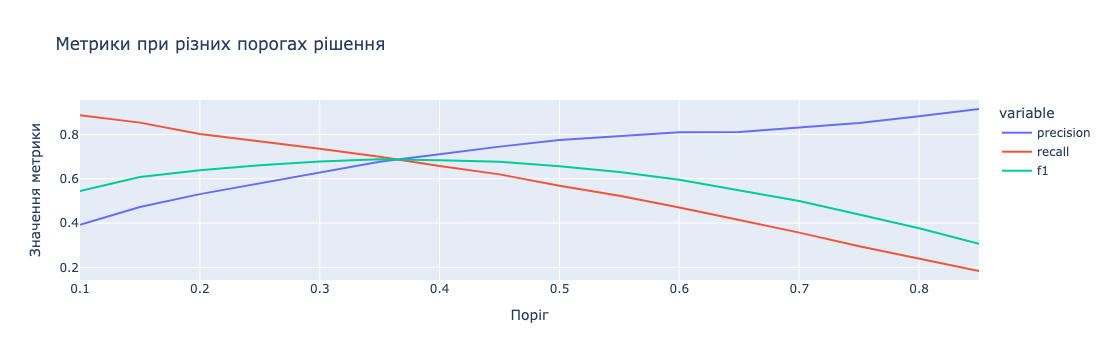

In [46]:
# Аналіз різних порогів
thresholds = np.arange(0.1, 0.9, 0.05)
metrics_by_threshold = []

# Отримуємо ймовірності 
y_pred_proba = log_reg.predict_proba(X_test_scaled)

for threshold in thresholds:
    y_pred_custom = (y_pred_proba[:, 1] >= threshold).astype(int)
    metrics_by_threshold.append({
        'threshold': threshold,
        'precision': precision_score(y_test, y_pred_custom),
        'recall': recall_score(y_test, y_pred_custom),
        'f1': f1_score(y_test, y_pred_custom)
    })

metrics_df = pd.DataFrame(metrics_by_threshold)

# Візуалізація 
fig = px.line(
    metrics_df.melt(id_vars='threshold'),
    x='threshold',
    y='value',
    color='variable',
    title='Метрики при різних порогах рішення',
    labels={'value': 'Значення метрики', 'threshold': 'Поріг'},
)
fig.show()

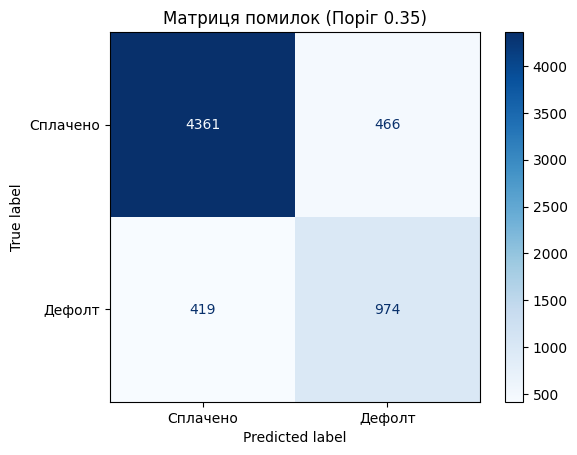

In [48]:
# Обираємо поріг 0.35, де F1-score досягає максимуму за графіком
y_pred_opt = (y_pred_proba[:, 1] >= 0.35).astype(int)

# Матриця помилок для оптимального порогу
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Сплачено', 'Дефолт'])
disp.plot(cmap='Blues')
plt.title('Матриця помилок (Поріг 0.35)')
plt.show()

Для оптимізації моделі було проведено аналіз метрик при різних порогах класифікації. Згідно з візуалізацією, пік значення F1-score (0.69) досягається при порозі 0.35.

При цьому порозі модель демонструє оптимальний баланс: вона виявляє значну частину дефолтів (Recall = 0.70), зберігаючи при цьому високу точність прогнозу (Precision = 0.68). Матриця помилок підтверджує, що кількість правильно вгаданих дефолтів (974) значно перевищує кількість помилкових спрацювань, що є вигідним для мінімізації фінансових ризиків банку.


---

## Завдання 7 (Опціональне): Покращення моделі та висновки (2 бали)

**Що потрібно зробити:**

На цих же даних навчіть DecisionTreeClassifier та RandomForestClassifier. Яка з трьох моделей дає найкращий результат на тестовому наборі?

Поріг класифікації можна для порівняння якостей моделей використовувати стандартний 0.5, або той, що ви виявили, як оптимальний на попередньому кроці.
